# Passive Scalar Transport with XLB — A Step-by-Step Tutorial

This notebook is the sequel to [the heat equation tutorial](heat_equation_2d.ipynb). There we
solved conduction in a motionless solid. Here we let the medium **move**, and the temperature
gets carried along with it.

The equation gains one term:

$$\rho c_p \left( \frac{\partial T}{\partial t}
+ \mathbf{u} \cdot \nabla T \right) = k \nabla^2 T + q''' ,$$

or, dividing by $\rho c_p$ and using $\nabla\cdot\mathbf{u} = 0$,

$$\frac{\partial T}{\partial t} + \nabla \cdot (T \mathbf{u}) = \alpha \nabla^2 T + S .$$

The new term $\mathbf{u} \cdot \nabla T$ is **advection**: heat being physically transported by
the moving fluid rather than trickling from hot to cold by conduction alone.

**What "passive" means.** The temperature is carried by the flow, but it does not affect the
flow in return. The velocity field is computed by the Navier-Stokes solver as if the
temperature did not exist, and then handed to the thermal solver. Physically this is the right
model whenever temperature differences are too small to change the density appreciably — dye
in water, a pollutant in air, or a mild temperature variation. It is also exactly how a
tracer behaves.

This makes the coupling **one-way**, which is a real simplification: the two solvers can be
advanced in sequence with no iteration.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import xlb
import xlb.velocity_set
from xlb.compute_backend import ComputeBackend
from xlb.grid import grid_factory
from xlb.helper import omega_from_diffusivity
from xlb.operator.boundary_condition import (
    EquilibriumBC,
    HalfwayBounceBackBC,
    ScalarDirichletBC,
    ScalarNeumannBC,
)
from xlb.operator.macroscopic import Macroscopic, ZeroMoment
from xlb.operator.stepper import IncompressibleNavierStokesStepper, ThermalStepper
from xlb.precision_policy import PrecisionPolicy

FIG_DIR = Path("figures/passive_scalar_transport_2d")
FIG_DIR.mkdir(parents=True, exist_ok=True)

---
## Step 1 — Advection enters through the equilibrium

Here is the pleasant surprise: adding advection requires **no new operator at all**. It is
already built into the equilibrium we used last time.

Recall the scalar equilibrium,

$$g_i^{\rm eq} = w_i \, T \left( 1 + 3\, \mathbf{c}_i \cdot \mathbf{u} \right).$$

In the previous notebook we set $\mathbf{u} = 0$ and the bracket collapsed to $1$. Supply a
non-zero $\mathbf{u}$ and the $3\,\mathbf{c}_i\cdot\mathbf{u}$ term biases the populations in
the direction of the flow, which is precisely advection. A Chapman-Enskog expansion of the
same BGK update then yields

$$\frac{\partial T}{\partial t} + \nabla\cdot(T\mathbf{u}) = \alpha \nabla^2 T + S$$

instead of the pure heat equation.

This is why `LinearEquilibrium` drops the quadratic velocity terms that the flow solver's
`QuadraticEquilibrium` carries. Those terms exist to recover the nonlinear
$\mathbf{u}\cdot\nabla\mathbf{u}$ of Navier-Stokes. A passive scalar has no such nonlinearity —
it is linear in $T$ — so the first-order equilibrium is not an approximation here but the
exactly appropriate choice.

### The practical consequence

All we have to do is fill in the `u` field that we previously left at zero:

```python
u, source = thermal_stepper.prepare_aux_fields()   # u is zero -> pure conduction
_, u = macroscopic(f_0)                            # u from the flow -> advection
```

One-way coupling reduces to recovering the velocity from the flow populations each step and
passing it in.

---
## Step 2 — Two solvers, two stencils

We now have two sets of populations living on the same grid:

| | Flow | Scalar |
|---|---|---|
| Populations | $f_i$ | $g_i$ |
| Stencil | **D2Q9** | **D2Q5** |
| Equilibrium | `QuadraticEquilibrium` | `LinearEquilibrium` |
| Moments used | $\rho$, $\rho\mathbf{u}$ | $T$ |
| Relaxation rate | $\omega$ from viscosity $\nu$ | $\omega_T$ from diffusivity $\alpha$ |
| Stepper | `IncompressibleNavierStokesStepper` | `ThermalStepper` |

The flow needs D2Q9 because momentum transport requires the diagonal links. The scalar is
happy with D2Q5. They genuinely can differ, and it saves both memory and work.

There is a wrinkle worth knowing about. `xlb.init` registers **one** default velocity set, and
it has to be the flow's D2Q9. Boundary conditions built by the user would therefore default to
D2Q9 even when they are meant for the scalar. `ThermalStepper` handles this for you: it
re-binds every boundary condition it is given to its own stencil at construction time. So you
construct `ScalarDirichletBC` exactly as you would in a standalone thermal run, and the
stepper sorts out the stencil.

### Two dimensionless numbers

The flow is characterized by the **Reynolds number** $\mathrm{Re} = UL/\nu$, comparing inertia
with viscosity. The scalar gets its own counterpart, the **Péclet number**,

$$\mathrm{Pe} = \frac{UL}{\alpha},$$

comparing advection with diffusion. At $\mathrm{Pe} \ll 1$ diffusion dominates and the
temperature barely notices the flow; at $\mathrm{Pe} \gg 1$ the temperature is swept along
field lines and forms thin boundary layers. Their ratio is the **Prandtl number**
$\mathrm{Pr} = \nu/\alpha = \mathrm{Pe}/\mathrm{Re}$, a property of the material: about 0.7 for
air, 7 for water, and 0.01 or less for liquid metals.

---
## Step 3 — Verify advection against an exact solution

Take a periodic
domain, impose a **uniform** velocity $u_x$ by hand (no flow solver needed), and drop in a
Gaussian blob. The exact solution translates and spreads at the same time:

$$T(x,t) = \frac{\sigma_0}{\sigma(t)}
\exp\!\left[-\frac{(x - x_0 - u_x t)^2}{2\sigma^2(t)}\right],
\qquad \sigma^2(t) = \sigma_0^2 + 2\alpha t .$$

The centre moves at exactly $u_x$ and the variance grows at exactly $2\alpha$ per step. This is
a sharp test: getting both right at once means advection and diffusion are each correctly
scaled, and it will expose the numerical diffusion that plagues naive advection schemes.

No GPU support is available; CPU fallback will be used.
Peclet number based on the blob width: 18.0
Blob should travel 250 cells in 5000 steps


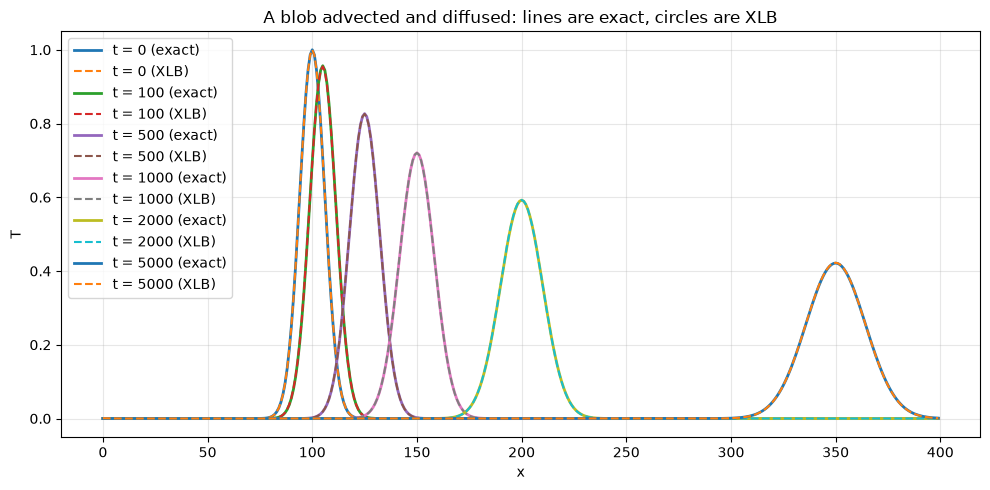

In [2]:
precision_policy = PrecisionPolicy.FP64FP64
compute_backend = ComputeBackend.JAX

d2q5 = xlb.velocity_set.D2Q5(precision_policy=precision_policy, compute_backend=compute_backend)
xlb.init(velocity_set=d2q5, default_backend=compute_backend, default_precision_policy=precision_policy)

nx_1d = 400
grid_1d = grid_factory((nx_1d, 3), compute_backend=compute_backend)

# No boundary conditions at all, so streaming wraps around in both directions
stepper_1d = ThermalStepper(grid=grid_1d, boundary_conditions=[])

alpha_1d = 1.0 / 60.0
omega_1d = omega_from_diffusivity(alpha_1d)
u_x = 0.05
num_steps_1d = 5000

x = np.arange(nx_1d)
sigma_0, x0 = 6.0, nx_1d // 4
phi_init = np.exp(-0.5 * ((x - x0) / sigma_0) ** 2)[None, :, None] * np.ones((1, nx_1d, 3))

g_0, g_1, bc_mask_1d, missing_mask_1d = stepper_1d.prepare_fields(phi_init=phi_init)
u_1d, source_1d = stepper_1d.prepare_aux_fields()

# This is the whole of "adding advection": put a velocity into the u field
u_1d = u_1d.at[0].set(u_x)

print(f"Peclet number based on the blob width: {u_x * sigma_0 / alpha_1d:.1f}")
print(f"Blob should travel {u_x * num_steps_1d:.0f} cells in {num_steps_1d} steps")

snapshots = {0: phi_init[0, :, 1].copy()}
snapshot_steps = [100, 500, 1000, 2000, 5000]

for i in range(num_steps_1d):
    g_0, g_1 = stepper_1d(g_0, g_1, u_1d, source_1d, bc_mask_1d, missing_mask_1d, omega_1d, i)
    g_0, g_1 = g_1, g_0
    if i + 1 in snapshot_steps:
        snapshots[i + 1] = np.asarray(ZeroMoment()(g_0))[0][:, 1]

plt.figure(figsize=(10, 5))

for step, profile in snapshots.items():
    sigma_t = np.sqrt(sigma_0**2 + 2.0 * alpha_1d * step)
    centre = x0 + u_x * step
    exact = sigma_0 / sigma_t * np.exp(-0.5 * ((x - centre) / sigma_t) ** 2)

    line = plt.plot(x, exact, "-", lw=2, label=f"t = {step} (exact)")[0]
    plt.plot(x, profile, "--", label=f"t = {step} (XLB)")

plt.xlabel("x")
plt.ylabel("T")
plt.title("A blob advected and diffused: lines are exact, circles are XLB")
plt.legend(ncols=1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "advected_blob.png", dpi=150)
plt.show()

The simulated blob sits on the exact solution at every snapshot. Let us put numbers on it by
measuring the first two moments of the profile.

In [3]:
print(f"{'step':>6}  {'centroid':>12} {'expected':>10}   {'variance':>12} {'expected':>10}")
for step, profile in snapshots.items():
    weights = profile / profile.sum()
    # Unwrap the periodic coordinate around the expected position so the tails are not
    # folded to the far side of the domain
    centre_expected = x0 + u_x * step
    x_unwrapped = (x - centre_expected + nx_1d / 2) % nx_1d - nx_1d / 2

    centroid = np.sum(weights * x_unwrapped) + centre_expected
    variance = np.sum(weights * (x_unwrapped - np.sum(weights * x_unwrapped)) ** 2)

    print(
        f"{step:>6}  {centroid:>12.3f} {centre_expected:>10.1f}   "
        f"{variance:>12.3f} {sigma_0**2 + 2.0 * alpha_1d * step:>10.3f}"
    )

  step      centroid   expected       variance   expected
     0       100.000      100.0         36.000     36.000
   100       104.973      105.0         39.472     39.333
   500       124.972      125.0         52.705     52.667
  1000       149.972      150.0         69.247     69.333
  2000       199.972      200.0        102.330    102.667
  5000       349.972      350.0        201.580    202.667


Both moments track the exact solution closely. The blob arrives where it should and has spread
by exactly the amount the diffusivity dictates — the extra spreading is $2\alpha t$ and nothing
more.

That last point deserves emphasis. A finite-difference upwind scheme would have added
substantial *numerical* diffusion here, smearing the blob far more than the physical $\alpha$
accounts for. The lattice Boltzmann scheme transports populations by exact shifts along lattice
links, so advection introduces no artificial smearing of its own, and the measured variance is
the physical one.

---
## Step 4 — A coupled simulation: the thermal lid-driven cavity

Now the real thing. We take the lid-driven cavity from the
[fluid tutorial](lid_driven_cavity_2d.ipynb) — a box whose top wall slides sideways, driving a
large recirculating vortex — and add a temperature field to it:

- **left wall hot** ($T = 1$), **right wall cold** ($T = 0$),
- **top and bottom insulated**, so heat can only travel between the side walls,
- the lid drives the flow, which then carries the heat around.

The competition is between conduction straight across from the hot wall to the cold wall, and
the vortex sweeping hot fluid around the cavity. That competition is what the Péclet number
measures.

### Setting the parameters

We pick $\mathrm{Re} = 200$ and $\mathrm{Pe} = 200$, so $\mathrm{Pr} = 1$: momentum and heat
diffuse at the same rate, which keeps the two boundary layers comparable in thickness and the
picture easy to read.

In [4]:
grid_shape = (128, 128)
precision_policy = PrecisionPolicy.FP64FP64

# The default velocity set must be the flow's D2Q9
flow_velocity_set = xlb.velocity_set.D2Q9(precision_policy=precision_policy, compute_backend=compute_backend)
xlb.init(
    velocity_set=flow_velocity_set,
    default_backend=compute_backend,
    default_precision_policy=precision_policy,
)

# The scalar keeps its own, cheaper stencil
thermal_velocity_set = xlb.velocity_set.D2Q5(precision_policy=precision_policy, compute_backend=compute_backend)

reynolds, peclet = 200.0, 200.0
prescribed_vel = 0.05
clength = grid_shape[0] - 1

viscosity = prescribed_vel * clength / reynolds
omega_flow = 1.0 / (3.0 * viscosity + 0.5)

diffusivity = prescribed_vel * clength / peclet
omega_thermal = omega_from_diffusivity(diffusivity)

print(f"Re = {reynolds:g}   Pe = {peclet:g}   Pr = {viscosity / diffusivity:.2f}")
print(f"viscosity   = {viscosity:.5f}  ->  omega_flow    = {omega_flow:.4f}")
print(f"diffusivity = {diffusivity:.5f}  ->  omega_thermal = {omega_thermal:.4f}")

grid = grid_factory(grid_shape, compute_backend=compute_backend)

No GPU support is available; CPU fallback will be used.
Re = 200   Pe = 200   Pr = 1.00
viscosity   = 0.03175  ->  omega_flow    = 1.6800
diffusivity = 0.03175  ->  omega_thermal = 1.6800


### Flow boundary conditions

Exactly as in the fluid tutorial: a moving lid via `EquilibriumBC`, and no-slip walls via
`HalfwayBounceBackBC`.

In [5]:
box = grid.bounding_box_indices()
box_no_edge = grid.bounding_box_indices(remove_edges=True)

lid = box_no_edge["top"]
walls = [box["bottom"][i] + box["left"][i] + box["right"][i] for i in range(flow_velocity_set.d)]
walls = np.unique(np.array(walls), axis=-1).tolist()

flow_stepper = IncompressibleNavierStokesStepper(
    grid=grid,
    boundary_conditions=[
        HalfwayBounceBackBC(indices=walls),
        EquilibriumBC(rho=1.0, u=(prescribed_vel, 0.0), indices=lid),
    ],
    collision_type="BGK",
)

f_0, f_1, bc_mask, missing_mask = flow_stepper.prepare_fields()

registered bc HalfwayBounceBackBC_302610274 with id 1
WARNING! Assuming no-slip condition for BC type = HalfwayBounceBackBC!
registered bc EquilibriumBC_303270727 with id 2
Warp 1.16.0 initialized:
   CUDA not enabled in this build
   Devices:
     "cpu"      : "arm"
   Kernel cache:
     /Users/rivas/Library/Caches/warp/1.16.0


### Thermal boundary conditions

These are **completely separate objects** from the flow boundary conditions, even where they
sit on the same nodes. Each carries its own registry id and acts on its own populations. A
node can perfectly well be a no-slip wall for the flow and a hot wall for the temperature —
indeed the left wall is exactly that.

As in the previous notebook, we give the corner nodes to the hot and cold walls, so the
insulated faces use `remove_edges=True`.

In [6]:
hot = box["left"]
cold = box["right"]
insulated = [box_no_edge["bottom"][i] + box_no_edge["top"][i] for i in range(thermal_velocity_set.d)]

thermal_stepper = ThermalStepper(
    grid=grid,
    boundary_conditions=[
        ScalarDirichletBC(value=1.0, indices=hot),
        ScalarDirichletBC(value=0.0, indices=cold),
        ScalarNeumannBC(flux=0.0, indices=insulated),
    ],
    velocity_set=thermal_velocity_set,
)

g_0, g_1, bc_mask_thermal, missing_mask_thermal = thermal_stepper.prepare_fields(phi_init=0.0)
u, source = thermal_stepper.prepare_aux_fields()

print(f"Flow populations:   {f_0.shape}   (D2Q9)")
print(f"Scalar populations: {g_0.shape}   (D2Q5)")
print("\nThe stepper re-bound its boundary conditions to the scalar stencil:")
for bc in thermal_stepper.boundary_conditions:
    print(f"  {bc.__class__.__name__:<20} q = {bc.velocity_set.q}")

registered bc ScalarDirichletBC_303270043 with id 3
registered bc ScalarDirichletBC_304392680 with id 4
registered bc ScalarNeumannBC_304392431 with id 5
Flow populations:   (9, 128, 128)   (D2Q9)
Scalar populations: (5, 128, 128)   (D2Q5)

The stepper re-bound its boundary conditions to the scalar stencil:
  ScalarDirichletBC    q = 5
  ScalarDirichletBC    q = 5
  ScalarNeumannBC      q = 5


### The coupled time loop

This is the heart of the notebook, and it is short. Each step:

1. advance the **flow** one step,
2. recover the **velocity** from the flow populations,
3. advance the **scalar** one step, using that velocity.

The order matters a little: the scalar is advected by the velocity of the flow field it has
just been given, so we recover `u` after the flow step rather than before.

In [7]:
macroscopic = Macroscopic()
zero_moment = ZeroMoment(
    velocity_set=thermal_velocity_set,
    precision_policy=precision_policy,
    compute_backend=compute_backend,
)

num_steps = 20000
report_every = 4000
nusselt_history = []


def nusselt_number(T):
    """Wall heat flow on the hot wall, normalized by the pure-conduction value.

    The halfway wall sits half a cell outside the first fluid column, so the wall gradient is
    estimated over that half-cell distance. Nu = 1 would mean the flow carries no more heat
    than conduction alone.
    """
    wall_gradient = (1.0 - T[0]) / 0.5
    conduction_gradient = 1.0 / grid_shape[0]
    return float(np.mean(wall_gradient) / conduction_gradient)


for i in range(num_steps):
    # 1. Advance the flow
    f_0, f_1 = flow_stepper(f_0, f_1, bc_mask, missing_mask, omega_flow, i)
    f_0, f_1 = f_1, f_0

    # 2. Recover the velocity and hand it to the scalar
    _, u = macroscopic(f_0)

    # 3. Advance the scalar, advected by that velocity
    g_0, g_1 = thermal_stepper(
        g_0, g_1, u, source, bc_mask_thermal, missing_mask_thermal, omega_thermal, i
    )
    g_0, g_1 = g_1, g_0

    if i % report_every == 0 or i == num_steps - 1:
        T = np.asarray(zero_moment(g_0))[0]
        nu = nusselt_number(T)
        nusselt_history.append((i, nu))
        print(f"step {i:>6d}   T in [{T.min():.4f}, {T.max():.4f}]   Nu = {nu:.3f}")

step      0   T in [0.0000, 0.6667]   Nu = 169.333
step   4000   T in [0.0000, 0.9863]   Nu = 7.560
step   8000   T in [0.0000, 0.9900]   Nu = 6.011
step  12000   T in [0.0000, 0.9914]   Nu = 5.403
step  16000   T in [0.0000, 0.9920]   Nu = 5.149
step  19999   T in [0.0001, 0.9922]   Nu = 5.063


Two things to note in that output.

The temperature stays within $[0, 1]$ throughout. It has to: a passive scalar obeys a maximum
principle, so it can never exceed the range set by its boundary values. Seeing values outside
that range would be a reliable sign of instability, usually from a Péclet number too high for
the grid.

The Nusselt number settles at roughly 5, meaning the stirring moves about five times as much
heat as conduction would on its own. That is the whole point of convective heat transfer, and
it is why heat sinks have fans.

---
## Step 5 — Look at the result

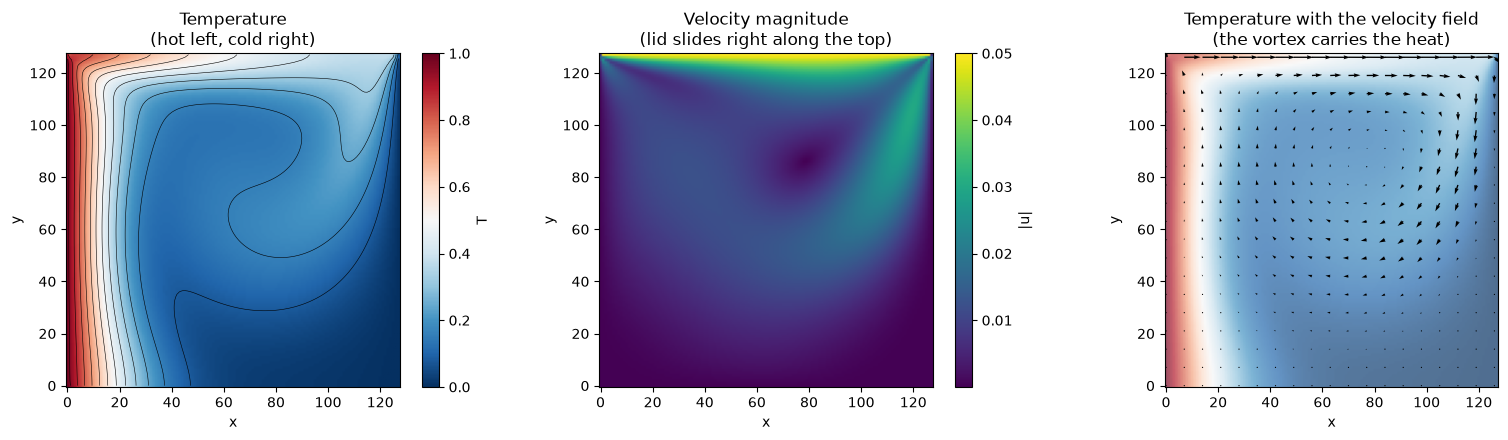

In [8]:
rho, u_final = macroscopic(f_0)
T = np.asarray(zero_moment(g_0))[0]
u_final = np.asarray(u_final)
u_magnitude = np.sqrt(u_final[0] ** 2 + u_final[1] ** 2)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

im = axes[0].imshow(T.T, origin="lower", cmap="RdBu_r", vmin=0, vmax=1)
axes[0].contour(T.T, levels=14, colors="k", linewidths=0.4)
axes[0].set_title("Temperature\n(hot left, cold right)")
fig.colorbar(im, ax=axes[0], label="T")

im = axes[1].imshow(u_magnitude.T, origin="lower", cmap="viridis")
axes[1].set_title("Velocity magnitude\n(lid slides right along the top)")
fig.colorbar(im, ax=axes[1], label="|u|")

skip = 7
xg, yg = np.meshgrid(np.arange(0, grid_shape[0], skip), np.arange(0, grid_shape[1], skip))
axes[2].imshow(T.T, origin="lower", cmap="RdBu_r", vmin=0, vmax=1, alpha=0.7)
axes[2].quiver(
    xg,
    yg,
    u_final[0, ::skip, ::skip].T,
    u_final[1, ::skip, ::skip].T,
    color="k",
    scale=0.8,
    width=0.004,
)
axes[2].set_title("Temperature with the velocity field\n(the vortex carries the heat)")

for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.tight_layout()
plt.savefig(FIG_DIR / "thermal_cavity.png", dpi=150)
plt.show()

The temperature field is nothing like the straight-line conduction profile of the previous
notebook. Instead:

- a **thin thermal boundary layer** hugs the hot left wall, where the fluid moving downward
  has not had time to warm up before it is swept away;
- hot fluid is **carried across the top** by the lid and dragged into the interior, producing
  the curled isotherms that trace out the vortex;
- the **core is well mixed** and nearly uniform, because the recirculation homogenizes it
  faster than conduction can build up a gradient.

That last feature is characteristic of high-Péclet transport: gradients get expelled from the
recirculating interior and compressed into thin layers at the walls. Since the wall heat flow
is set by the thickness of those layers, thinner layers mean more heat transfer, which is
exactly what the Nusselt number of about 5 was telling us.

---
## Step 6 — The Péclet number controls the picture

To see how much the flow really matters, let us sweep the Péclet number while holding the flow
fixed. Only the scalar diffusivity changes.

- $\mathrm{Pe} = 20$: diffusion is still strong enough to keep the isotherms close to the
  straight-line conduction profile of the previous notebook.
- $\mathrm{Pe} = 100$: the two mechanisms are comparable and the vortex starts to show.
- $\mathrm{Pe} = 500$: advection dominates, with thin wall layers and a well-mixed core.

### Why not sweep further?

The range is not chosen for convenience — it is set by the $\omega$ constraint from the
previous notebook. Since $\mathrm{Pe} = UL/\alpha$ with $U$ and $L$ fixed by the flow, choosing
$\mathrm{Pe}$ *is* choosing $\alpha$, and we wanted to stay in the well-behaved band
$\alpha \in [0.01, 0.5]$. Here $UL = 6.35$, so that band admits roughly
$\mathrm{Pe} \in [13, 635]$.

Going outside it does not fail immediately, but it degrades: low $\mathrm{Pe}$ forces
$\alpha$ large and $\omega \to 0$, where the scheme becomes over-diffusive and slow to relax;
high $\mathrm{Pe}$ forces $\omega \to 2$, where it grows noisy. To reach a genuinely higher
Péclet number you change the *physical* setup rather than just $\omega$ — refine the grid to
increase $L$ in lattice units, which is also what the thinning boundary layers require anyway.

We reuse the already-converged flow field, so only the thermal solver runs in this loop.

In [14]:
results = {}

for pe in [20.0, 100.0, 500.0]:
    alpha_pe = prescribed_vel * clength / pe
    omega_pe = omega_from_diffusivity(alpha_pe)

    stepper_pe = ThermalStepper(
        grid=grid,
        boundary_conditions=[
            ScalarDirichletBC(value=1.0, indices=hot),
            ScalarDirichletBC(value=0.0, indices=cold),
            ScalarNeumannBC(flux=0.0, indices=insulated),
        ],
        velocity_set=thermal_velocity_set,
    )

    gp_0, gp_1, bcm, mm = stepper_pe.prepare_fields(phi_init=0.0)
    _, src = stepper_pe.prepare_aux_fields()

    for i in range(20000):
        gp_0, gp_1 = stepper_pe(gp_0, gp_1, u, src, bcm, mm, omega_pe, i)
        gp_0, gp_1 = gp_1, gp_0

    T_pe = np.asarray(zero_moment(gp_0))[0]
    results[pe] = T_pe
    print(f"Pe = {pe:>6.0f}   alpha = {alpha_pe:.5f}   omega = {omega_pe:.4f}   Nu = {nusselt_number(T_pe):.3f}")

registered bc ScalarDirichletBC_303263130 with id 15
registered bc ScalarDirichletBC_324861530 with id 16
registered bc ScalarNeumannBC_324672976 with id 17
Pe =     20   alpha = 0.31750   omega = 0.6885   Nu = 1.466
registered bc ScalarDirichletBC_324812135 with id 18
registered bc ScalarDirichletBC_303271043 with id 19
registered bc ScalarNeumannBC_324881214 with id 20
Pe =    100   alpha = 0.06350   omega = 1.4482   Nu = 3.645
registered bc ScalarDirichletBC_304412544 with id 21
registered bc ScalarDirichletBC_303350389 with id 22
registered bc ScalarNeumannBC_303318996 with id 23
Pe =    500   alpha = 0.01270   omega = 1.8584   Nu = 8.155


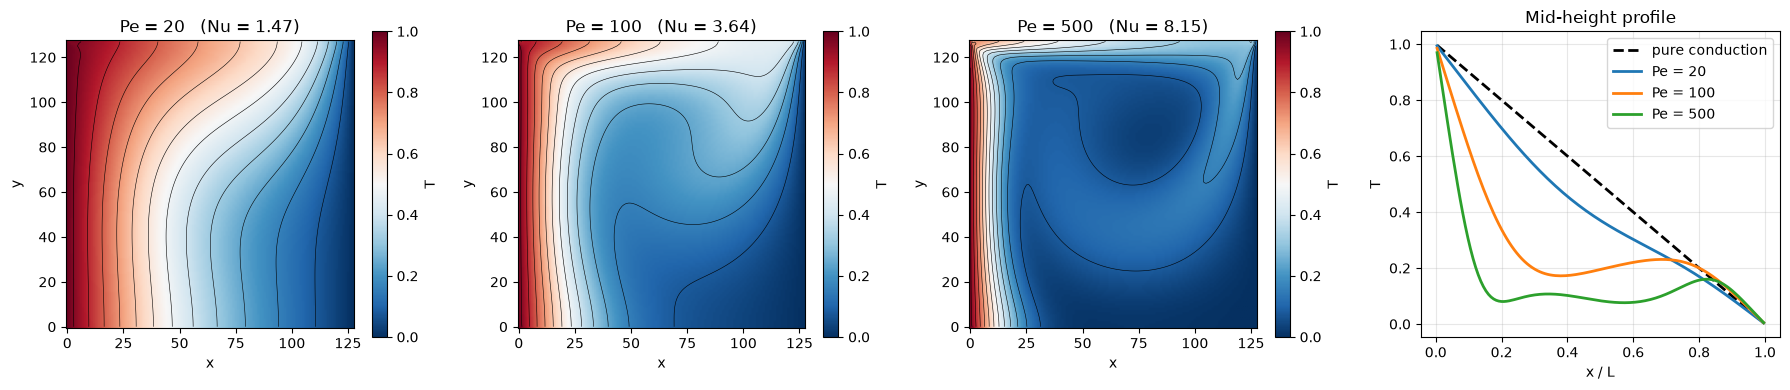

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (pe, T_pe) in zip(axes[:3], results.items()):
    im = ax.imshow(T_pe.T, origin="lower", cmap="RdBu_r", vmin=0, vmax=1)
    ax.contour(T_pe.T, levels=14, colors="k", linewidths=0.4)
    ax.set_title(f"Pe = {pe:.0f}   (Nu = {nusselt_number(T_pe):.2f})")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.colorbar(im, ax=ax, label="T")

x_over_L = (np.arange(grid_shape[0]) + 0.5) / grid_shape[0]
axes[3].plot(x_over_L, 1.0 - x_over_L, "k--", lw=2, label="pure conduction")
for pe, T_pe in results.items():
    axes[3].plot(x_over_L, T_pe[:, grid_shape[1] // 2], lw=2, label=f"Pe = {pe:.0f}")
axes[3].set_xlabel("x / L")
axes[3].set_ylabel("T")
axes[3].set_title("Mid-height profile")
axes[3].legend()
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "peclet_sweep.png", dpi=150)
plt.show()

The progression is exactly as advertised. At $\mathrm{Pe} = 20$ the isotherms are still
close to vertical and the mid-height profile is not far from the conduction straight line —
the flow is there, but diffusion smooths out its effect nearly as fast as it can act. As
$\mathrm{Pe}$ rises the isotherms wrap around the vortex, the profile flattens in the core, and
the gradients pile up against the side walls.

Watch the Nusselt number as well: it climbs steadily with $\mathrm{Pe}$, quantifying the
extra heat that stirring delivers. This is the essential idea behind all convective cooling,
and note that we obtained the whole sweep by changing a single number, `omega_thermal`, while
reusing one flow solution.

### A caution on high Péclet numbers

There is a limit to how far you can push this. At high $\mathrm{Pe}$ the thermal boundary
layers thin out as $\mathrm{Pe}^{-1/2}$, and once a layer is thinner than a cell the grid can
no longer represent it: the solution develops oscillations and may leave the $[0,1]$ range.
The remedies are the usual ones — refine the grid, or lower the velocity. Checking that the
temperature has stayed within its boundary values, as we did above, is a quick and reliable
way to catch this.

**Next:** Step 7 cross-checks the LBM result at $\mathrm{Pe}=20$ against an independent
finite-difference solve of the same steady equation.

---
## Step 7 — Cross-check with a finite-difference solver

As a final sanity check, we can solve the **same steady problem** with a conventional
finite-difference (FD) scheme on the same grid and the same velocity field $\mathbf{u}$
recovered from the flow solver.

At steady state and with $\nabla\cdot\mathbf{u}=0$, the passive scalar equation is

$$
\mathbf{u}\cdot\nabla\phi = \alpha \nabla^2 \phi .
$$

The FD code below time-marches this equation with **upwind advection** and a **central
Laplacian**, using the same boundary data as the LBM run:

- $\phi = 1$ on the left, $\phi = 0$ on the right (Dirichlet),
- $\partial\phi/\partial y = 0$ on the top and bottom (adiabatic, enforced by mirroring).

### When is this a fair comparison?

| Regime | Verdict |
|--------|---------|
| **Low–moderate Pe** (e.g. Pe $= 20$) | Good cross-check. Interior profiles agree to a few percent. |
| **High Pe** (e.g. Pe $= 500$) | **Not** a fair reference on the *same* grid. Upwind FD adds $\mathcal{O}(\|u\|\Delta x)$ numerical diffusion, which smears thin thermal boundary layers that LBM captures more sharply. |

There is also a subtle wall-placement difference: LBM Dirichlet walls sit **half a cell
outside** the fluid node (halfway link), whereas the FD stencil pins $\phi$ on the boundary
column directly. That mostly affects the first column and the Nusselt number, not the interior
profile we compare below.

We therefore use the FD solver as a **qualitative cross-check at Pe $= 20$**, not as a
high-Péclet reference solution.

In [16]:
def steady_scalar_fd(u, alpha, max_iter=300_000, tol=1e-9):
    """Steady advection--diffusion via pseudo-time: u·grad(phi) = alpha laplacian(phi).

  Uses first-order upwind advection and a five-point Laplacian on the same cell-centred
  grid as the LBM solver. Returns the converged temperature field and iteration count.
    """
    nx, ny = u.shape[1], u.shape[2]
    phi = np.zeros((nx, ny))
    phi[0, :] = 1.0
    phi[-1, :] = 0.0

    ux, uy = u[0], u[1]
    umax = max(float(np.max(np.abs(ux))), float(np.max(np.abs(uy))), 1e-12)
    dt = 0.45 * min(1.0 / (4.0 * alpha + 1e-12), 1.0 / umax)

    for it in range(max_iter):
        phi_old = phi.copy()

        lap = np.zeros_like(phi)
        lap[1:-1, 1:-1] = (
            phi[:-2, 1:-1]
            + phi[2:, 1:-1]
            + phi[1:-1, :-2]
            + phi[1:-1, 2:]
            - 4.0 * phi[1:-1, 1:-1]
        )

        dphidx_m = phi[1:-1, 1:-1] - phi[:-2, 1:-1]
        dphidx_p = phi[2:, 1:-1] - phi[1:-1, 1:-1]
        dphidy_m = phi[1:-1, 1:-1] - phi[1:-1, :-2]
        dphidy_p = phi[1:-1, 2:] - phi[1:-1, 1:-1]
        dphidx = np.where(ux[1:-1, 1:-1] >= 0.0, dphidx_m, dphidx_p)
        dphidy = np.where(uy[1:-1, 1:-1] >= 0.0, dphidy_m, dphidy_p)
        adv = ux[1:-1, 1:-1] * dphidx + uy[1:-1, 1:-1] * dphidy

        phi[1:-1, 1:-1] += dt * (-adv + alpha * lap[1:-1, 1:-1])

        phi[0, :] = 1.0
        phi[-1, :] = 0.0
        phi[:, 0] = phi[:, 1]
        phi[:, -1] = phi[:, -2]

        if np.max(np.abs(phi - phi_old)) < tol:
            return phi, it + 1

    return phi, max_iter


pe_check = 20.0
T_lbm = results[pe_check]
alpha_check = prescribed_vel * clength / pe_check
T_fd, fd_iters = steady_scalar_fd(u, alpha_check)

# Compare in the interior only (away from the wall-placement difference at x = 0)
interior = (slice(4, -4), slice(4, -4))
rel_l2 = np.linalg.norm((T_lbm - T_fd)[interior]) / np.linalg.norm(T_fd[interior])
max_abs = np.abs(T_lbm - T_fd)[interior].max()

print(f"Pe = {pe_check:.0f}")
print(f"  FD iterations to steady state: {fd_iters}")
print(f"  Interior relative L2 error:    {rel_l2:.3f}")
print(f"  Interior max |T_LBM - T_FD|:   {max_abs:.4f}")
print(f"  Nu (LBM) = {nusselt_number(T_lbm):.3f}   Nu (FD, same formula) = {nusselt_number(T_fd):.3f}")
print("  (Nusselt numbers differ near the wall because of the halfway-wall placement in LBM.)")

Pe = 20
  FD iterations to steady state: 139103
  Interior relative L2 error:    0.010
  Interior max |T_LBM - T_FD|:   0.0293
  Nu (LBM) = 1.466   Nu (FD, same formula) = 0.000
  (Nusselt numbers differ near the wall because of the halfway-wall placement in LBM.)


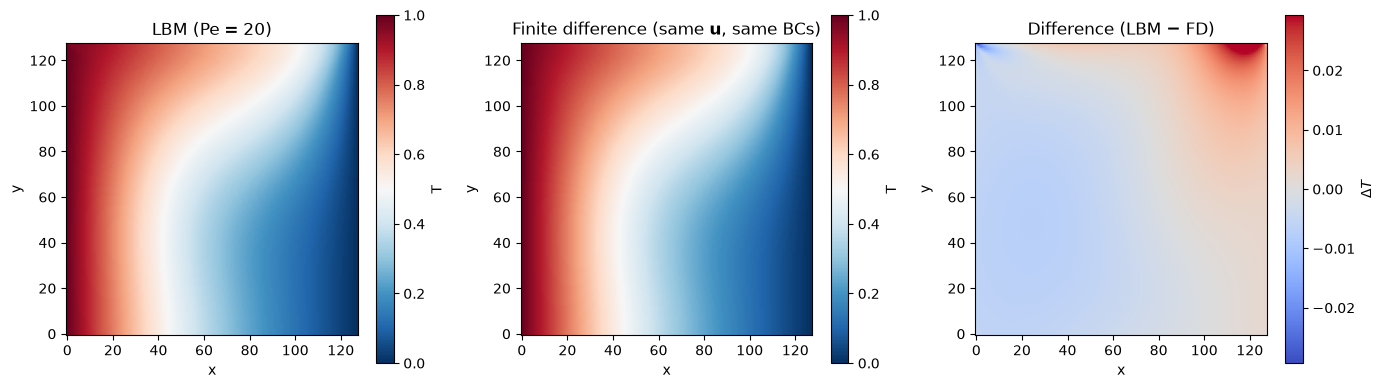

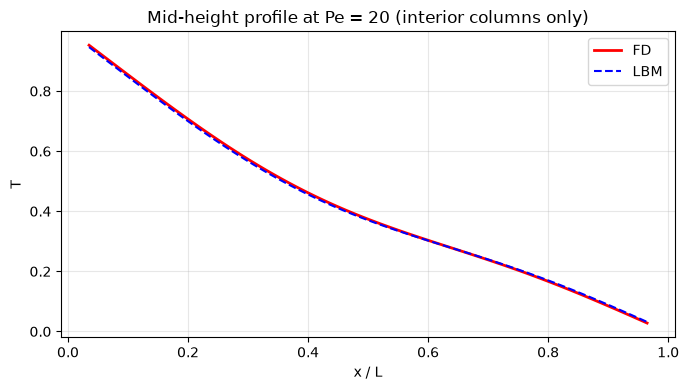

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im = axes[0].imshow(T_lbm.T, origin="lower", cmap="RdBu_r", vmin=0, vmax=1)
axes[0].set_title(f"LBM (Pe = {pe_check:.0f})")
fig.colorbar(im, ax=axes[0], label="T")

im = axes[1].imshow(T_fd.T, origin="lower", cmap="RdBu_r", vmin=0, vmax=1)
axes[1].set_title("Finite difference (same $\\mathbf{u}$, same BCs)")
fig.colorbar(im, ax=axes[1], label="T")

diff = T_lbm - T_fd
vlim = np.max(np.abs(diff[interior]))
im = axes[2].imshow(diff.T, origin="lower", cmap="coolwarm", vmin=-vlim, vmax=vlim)
axes[2].set_title("Difference (LBM $-$ FD)")
fig.colorbar(im, ax=axes[2], label="$\\Delta T$")

for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.tight_layout()
plt.savefig(FIG_DIR / "fd_crosscheck_pe20.png", dpi=150)
plt.show()

# Mid-height profile away from the hot-wall column
j_mid = grid_shape[1] // 2
x_plot = (np.arange(4, grid_shape[0] - 4) + 0.5) / grid_shape[0]
plt.figure(figsize=(7, 4))
plt.plot(x_plot, T_fd[4:-4, j_mid], "r-", lw=2, label="FD")
plt.plot(x_plot, T_lbm[4:-4, j_mid], "b--", label="LBM")
plt.xlabel("x / L")
plt.ylabel("T")
plt.title(f"Mid-height profile at Pe = {pe_check:.0f} (interior columns only)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "fd_crosscheck_profile_pe20.png", dpi=150)
plt.show()